# Introduction to Generative AI
## AIAT 111 - Unit 1: Introduction to AI and Applications

**Note:** Full coverage of Generative AI will be in Course 10 (AIAT 124). This is an introduction.

---

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand what generative AI is
- Learn about generative AI frameworks
- Explore applications of generative AI
- Understand ethical considerations
- Get hands-on with simple generative AI examples

---

## 🔗 Where this fits

**Builds on:** Unit 1, lesson 01 "AI Introduction" — generative AI is placed inside the AI/ML/DL map drawn there.

**Used later in:** Course 10 (AIAT 124) — Unit 1, the full generative-AI course; and Unit 5 of this course, where you train a GAN yourself.

---


## 🎯 The comic book that could only be half copyrighted

Kris Kashtanova wrote and published *Zarya of the Dawn*, a graphic novel whose
images were produced with Midjourney, and registered it with the **US Copyright
Office**. On **21 February 2023** the Office issued its decision: the **text** she
wrote is protected, and so is her **selection, coordination and arrangement** of
the images — but the **images themselves are not**. Its reasoning is worth
quoting for this notebook: a person who supplies text prompts "does not 'actually
form' the generated images and is not the 'master mind' behind them"; the prompt
"may 'influence' the generated image, but prompt text does not dictate a specific
result".

That is a real decision with real consequences — for illustrators, publishers,
and any company planning to build a product on generated assets — and it turns on
a technical fact you are about to see with your own eyes in the last cell of this
notebook. A generative model **samples**. Run it twice on the same input and you
get two different outputs. The person holding the prompt is steering, not drawing.

### What goes wrong if you cannot tell generation from classification

They fail in opposite ways, so they need opposite safeguards. A classifier that
is wrong gives you a wrong label you can check against the truth. A generator that
is wrong gives you a **fluent, plausible, entirely invented** output with nothing
to check it against — and its confidence looks exactly the same as when it is
right. Teams that treat a generator like a classifier ship the first product that
confidently makes things up. Keep that asymmetry in mind through the whole of Unit 5
and Course 10.


### 🧰 Bridge: three words this preview uses

This is a *preview* notebook — machine learning is taught properly in Units 2-3.
Until then, three plain-language definitions are all you need:

- A **model** is a program whose behavior is set by learning from examples, not by
  hand-written rules alone.
- **Training data** is the collection of examples the model learns from.
- **Classify vs generate**: a classifying model answers a question about its input
  ("is this spam?"); a generative model produces *new* content shaped like its
  training data ("write an email").

Terms like *latent space* or *attention* appear below only as vocabulary — they are
explained for real in Course 10 (AIAT 124).


## 1. What is Generative AI?

Generative AI refers to AI systems that can generate new content, such as text, images, audio, or video, rather than just analyzing or classifying existing data.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# The one distinction this whole unit hangs on: discriminative models LABEL existing
# data, generative models CREATE new data. Keep this contrast in mind for the demo below.
# Generative AI Overview

print("""
Generative AI vs Discriminative AI:

Discriminative AI:
- Classifies or predicts based on input
- Example: Spam email classifier
- Answers: "Is this spam?" (Yes/No)

Generative AI:
- Creates new content similar to training data
- Example: Text generator
- Answers: "What would a spam email look like?" (Generates content)
""")


Generative AI vs Discriminative AI:

Discriminative AI:
- Classifies or predicts based on input
- Example: Spam email classifier
- Answers: "Is this spam?" (Yes/No)

Generative AI:
- Creates new content similar to training data
- Example: Text generator
- Answers: "What would a spam email look like?" (Generates content)



## 2. Generative AI Frameworks and Types

Main types of generative models:


In [2]:
# The four main families of generative models you will meet later in the diploma —
# GANs, VAEs, Transformers, and diffusion models — with what each is used for.
# Types of Generative AI Models

generative_models = {
    'GANs': {
        'full_name': 'Generative Adversarial Networks',
        'description': 'Two networks competing: generator creates, discriminator evaluates',
        'applications': ['Image generation', 'Face generation', 'Style transfer']
    },
    'VAEs': {
        'full_name': 'Variational Autoencoders',
        'description': 'Encode data to latent space, decode to generate new data',
        'applications': ['Image reconstruction', 'Anomaly detection', 'Data generation']
    },
    'Transformers': {
        'full_name': 'Transformer Models',
        'description': 'Attention-based models for sequence generation',
        'applications': ['Text generation', 'Language translation', 'Chatbots']
    },
    'Diffusion Models': {
        'full_name': 'Diffusion Probabilistic Models',
        'description': 'Generate data by reversing a diffusion process',
        'applications': ['Image generation (DALL-E, Stable Diffusion)', 'Audio generation']
    }
}

for model_type, info in generative_models.items():
    print(f"\n{model_type} ({info['full_name']})")
    print(f"  Description: {info['description']}")
    print(f"  Applications: {', '.join(info['applications'])}")


GANs (Generative Adversarial Networks)
  Description: Two networks competing: generator creates, discriminator evaluates
  Applications: Image generation, Face generation, Style transfer

VAEs (Variational Autoencoders)
  Description: Encode data to latent space, decode to generate new data
  Applications: Image reconstruction, Anomaly detection, Data generation

Transformers (Transformer Models)
  Description: Attention-based models for sequence generation
  Applications: Text generation, Language translation, Chatbots

Diffusion Models (Diffusion Probabilistic Models)
  Description: Generate data by reversing a diffusion process
  Applications: Image generation (DALL-E, Stable Diffusion), Audio generation


## 3. Applications and Ethical Considerations

Important ethical concerns with generative AI:


In [3]:
# Generative AI is powerful enough to cause harm; these four concerns (bias,
# misinformation, IP, privacy) come up in every real deployment discussion.
# Ethical Considerations in Generative AI

ethical_concerns = {
    'Bias': {
        'issue': 'Generative models can perpetuate biases from training data',
        'example': 'AI-generated images may reinforce stereotypes',
        'mitigation': 'Diverse training data, bias detection techniques'
    },
    'Misinformation': {
        'issue': 'Ability to generate convincing fake content',
        'example': 'Deepfakes, fake news generation',
        'mitigation': 'Content verification, watermarking, regulations'
    },
    'Intellectual Property': {
        'issue': 'Who owns AI-generated content?',
        'example': 'Copyright of AI-generated art or text',
        'mitigation': 'Clear regulations and legal frameworks'
    },
    'Privacy': {
        'issue': 'Models can memorize and leak personal data from training sets',
        'example': 'A model reproducing someone\'s photo, address, or medical text',
        'mitigation': 'Data anonymization, deduplication, differential privacy'
    }
}

print("Ethical Considerations in Generative AI:\n")
for concern, details in ethical_concerns.items():
    print(f"{concern}:")
    print(f"  Issue: {details['issue']}")
    print(f"  Example: {details['example']}")
    print(f"  Mitigation: {details['mitigation']}")
    print()

Ethical Considerations in Generative AI:

Bias:
  Issue: Generative models can perpetuate biases from training data
  Example: AI-generated images may reinforce stereotypes
  Mitigation: Diverse training data, bias detection techniques

Misinformation:
  Issue: Ability to generate convincing fake content
  Example: Deepfakes, fake news generation
  Mitigation: Content verification, watermarking, regulations

Intellectual Property:
  Issue: Who owns AI-generated content?
  Example: Copyright of AI-generated art or text
  Mitigation: Clear regulations and legal frameworks

Privacy:
  Issue: Models can memorize and leak personal data from training sets
  Example: A model reproducing someone's photo, address, or medical text
  Mitigation: Data anonymization, deduplication, differential privacy



## 4. Hands-On: A Tiny Generative Model (Markov Chain)

Everything above described generative AI — now let's *build* the smallest possible
generative model: a **word-level Markov chain**.

It has the two ingredients every generative model shares:

1. **Learn** — count which word follows which in a small training corpus.
2. **Generate** — start from a word and repeatedly sample a plausible next word.

Large language models do the same *predict-the-next-word* job, just with a neural
network over billions of examples instead of a frequency table over six sentences.


In [4]:
# The smallest possible generative model: a word-level Markov chain. It has the two
# ingredients of ALL generative AI — learn patterns from data, then sample new content from them.
# Hands-on: a word-level Markov chain — learn from data, then generate
import random

# Training corpus: six tiny sentences about household robots
corpus = """
the robot cleans the kitchen
the robot charges its battery
the vacuum cleans the floor
the robot sees the floor
the vacuum charges its battery
the robot cleans the floor quickly
"""

# 1) LEARN: count word -> possible-next-word transitions from the corpus
transitions = {}
for line in corpus.strip().split('\n'):
    words = line.split()
    for current_word, next_word in zip(words, words[1:] + ['<END>']):
        transitions.setdefault(current_word, []).append(next_word)

print("Learned transitions (word -> possible next words):")
for word, next_words in transitions.items():
    print(f"  {word:9s} -> {next_words}")

# 2) GENERATE: start from a word and sample the next word repeatedly
random.seed(12)

def generate_sentence(start_word, max_words=8):
    word = start_word
    sentence = [word]
    for _ in range(max_words):
        next_word = random.choice(transitions[word])
        if next_word == '<END>':
            break
        sentence.append(next_word)
        word = next_word
    return ' '.join(sentence)

print("\nGenerated sentences:")
for i in range(4):
    print(f"  {i + 1}. {generate_sentence('the')}")

print("\nLook closely: some outputs repeat training lines, but others are NEW")
print("combinations the corpus never contained. The model LEARNED patterns from")
print("data and SAMPLED new content from them — generative AI in miniature.")

Learned transitions (word -> possible next words):
  the       -> ['robot', 'kitchen', 'robot', 'vacuum', 'floor', 'robot', 'floor', 'vacuum', 'robot', 'floor']
  robot     -> ['cleans', 'charges', 'sees', 'cleans']
  cleans    -> ['the', 'the', 'the']
  kitchen   -> ['<END>']
  charges   -> ['its', 'its']
  its       -> ['battery', 'battery']
  battery   -> ['<END>', '<END>']
  vacuum    -> ['cleans', 'charges']
  floor     -> ['<END>', '<END>', 'quickly']
  sees      -> ['the']
  quickly   -> ['<END>']

Generated sentences:
  1. the vacuum charges its battery
  2. the robot sees the floor quickly
  3. the floor
  4. the robot cleans the floor

Look closely: some outputs repeat training lines, but others are NEW
combinations the corpus never contained. The model LEARNED patterns from
data and SAMPLED new content from them — generative AI in miniature.


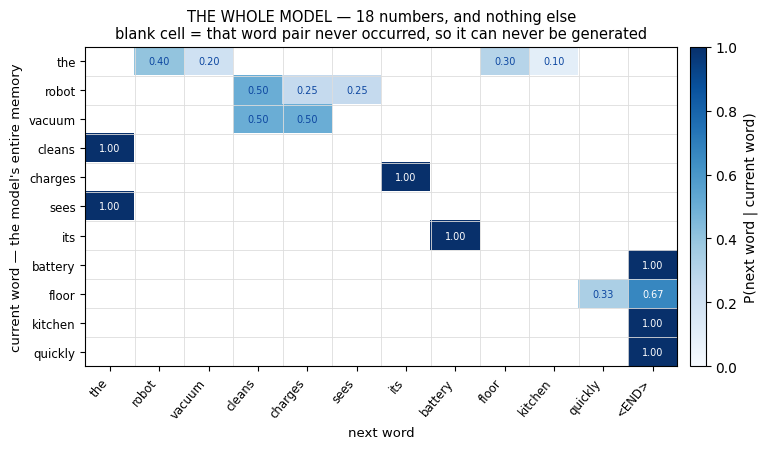

The model is 18 numbers over a vocabulary of 11 words.
The grid has 132 cells, so 86% of it is empty — every empty cell is an output the model can never produce.


In [5]:
# ── Picture 1: the model, every number of it ────────────────────────────────
# WHAT: draw the transition counts you just printed as a probability table.
# WHY : "a model" sounds enormous. This one fits on a screen, and seeing all of it
#       is what makes its two hard limits — one-word memory, closed vocabulary — real.
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

ROWS = ['the', 'robot', 'vacuum', 'cleans', 'charges', 'sees',
        'its', 'battery', 'floor', 'kitchen', 'quickly']
COLS = ROWS + ['<END>']
M = np.full((len(ROWS), len(COLS)), np.nan)          # NaN = this pair was never seen
for i, w in enumerate(ROWS):
    nxt = Counter(transitions[w])
    total = sum(nxt.values())
    for j, c in enumerate(COLS):
        if nxt[c]:
            M[i, j] = nxt[c] / total
n_filled = int(np.sum(~np.isnan(M)))

fig1, ax1 = plt.subplots(figsize=(7.8, 4.6))
im = ax1.imshow(np.ma.masked_invalid(M), cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax1.set_xticks(range(len(COLS))); ax1.set_xticklabels(COLS, rotation=50, ha='right', fontsize=8.5)
ax1.set_yticks(range(len(ROWS))); ax1.set_yticklabels(ROWS, fontsize=8.5)
ax1.set_xlabel('next word', fontsize=9.5)
ax1.set_ylabel("current word — the model's entire memory", fontsize=9.5)
for i in range(len(ROWS)):
    for j in range(len(COLS)):
        if not np.isnan(M[i, j]):
            ax1.text(j, i, f"{M[i, j]:.2f}", ha='center', va='center', fontsize=7,
                     color='white' if M[i, j] > 0.55 else '#0d47a1')
ax1.set_xticks(np.arange(-.5, len(COLS), 1), minor=True)
ax1.set_yticks(np.arange(-.5, len(ROWS), 1), minor=True)
ax1.grid(which='minor', color='#dddddd', linewidth=0.6)
ax1.tick_params(which='minor', length=0)
ax1.set_title(f"THE WHOLE MODEL — {n_filled} numbers, and nothing else\n"
              "blank cell = that word pair never occurred, so it can never be generated",
              fontsize=10.5)
fig1.colorbar(im, ax=ax1, fraction=0.032, pad=0.02, label='P(next word | current word)')
fig1.tight_layout()
plt.show()

print(f"The model is {n_filled} numbers over a vocabulary of {len(ROWS)} words.")
print(f"The grid has {M.size} cells, so {100 * (1 - n_filled / M.size):.0f}% of it is empty — "
      "every empty cell is an output the model can never produce.")


### 👁️ Read the model table

**This is not a summary of the model — it is all of it.** Eleven rows (the word it is
looking at), twelve columns (the word it might say next, `<END>` included), and
**18 filled cells**.

Read the top row: given `the`, the model says `robot` 40% of the time, `floor` 30%,
`vacuum` 20%, `kitchen` 10%. Read `floor`: 67% it stops, 33% it says `quickly`. Rows
like `cleans`, `charges`, `its` and `sees` hold a single `1.00` — those words offer no
choice at all.

Two limits are visible here that the printed transition list does not make obvious:

- **The blanks are the model's hard wall.** Most of the grid is empty. There is no
  column for *dishwasher*, so no amount of running can ever produce that word. That is
  the "it can only emit words it has seen" limit further down the page, as a picture.
- **One row is the entire memory.** To choose its next word the model reads exactly one
  row and nothing else — not the row before, not the beginning of the sentence. Every
  later advance in language modelling is a way of using more than one row.


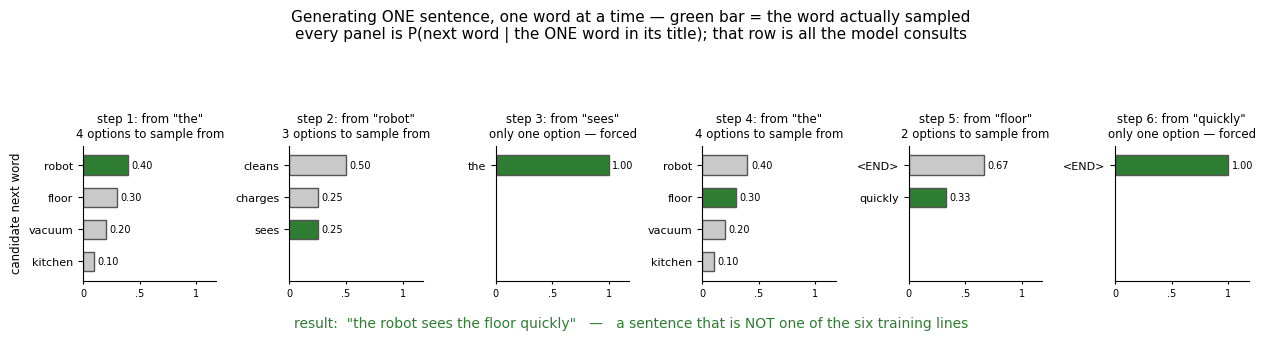

step  reads row options  sampled   P(sampled)
   1  the             4  robot           0.40
   2  robot           3  sees            0.25
   3  sees            1  the             1.00
   4  the             4  floor           0.30
   5  floor           2  quickly         0.33
   6  quickly         1  <END>           1.00

sentence built: "the robot sees the floor quickly"
in the training corpus? False


In [6]:
# ── Picture 2: watch ONE sentence being generated, word by word ─────────────
# WHAT: run the generator once, and draw the choice it faced at every single step —
#       the distribution it read, and the word it sampled out of it.
# WHY : generation is a PROCESS. This is the storyboard of one run: six panels, six
#       decisions, and you can see which were real choices and which were forced.
# NOTE: random.choice here is not fabricated data — the sampling IS the lesson.
import random

random.seed(30)                       # fixed so the classroom sees the same run
word = 'the'
run_steps = []
for _ in range(8):
    chosen = random.choice(transitions[word])
    run_steps.append({'from': word, 'picked': chosen})
    if chosen == '<END>':
        break
    word = chosen
sentence = ' '.join(step['from'] for step in run_steps)
training_lines = [line.strip() for line in corpus.strip().split('\n')]

n_panels = len(run_steps)
fig2, axes = plt.subplots(1, n_panels, figsize=(2.12 * n_panels, 3.3))
for k, (ax, step) in enumerate(zip(axes, run_steps), start=1):
    counts = Counter(transitions[step['from']])
    total = sum(counts.values())
    options = sorted(counts, key=lambda w: -counts[w])
    probs = [counts[o] / total for o in options]
    colours = ['#2e7d32' if o == step['picked'] else '#c9c9c9' for o in options]
    y = list(range(len(options)))
    ax.barh(y, probs, color=colours, edgecolor='#555555', height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(options, fontsize=8)
    ax.set_ylim(3.6, -0.6)            # same four slots in every panel -> comparable bars
    ax.set_xlim(0, 1.18)
    ax.set_xticks([0, 0.5, 1.0]); ax.set_xticklabels(['0', '.5', '1'], fontsize=7)
    for yy, p in zip(y, probs):
        ax.text(p + 0.03, yy, f"{p:.2f}", va='center', fontsize=7)
    note = ("only one option — forced" if len(options) == 1
            else f"{len(options)} options to sample from")
    ax.set_title(f'step {k}: from "{step["from"]}"\n{note}', fontsize=8.5)
    ax.tick_params(axis='x', length=2)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
axes[0].set_ylabel('candidate next word', fontsize=8.5)
fig2.suptitle('Generating ONE sentence, one word at a time — green bar = the word actually sampled\n'
              'every panel is P(next word | the ONE word in its title); that row is all the model consults',
              fontsize=11)
fig2.text(0.5, 0.015,
          f'result:  "{sentence}"   —   '
          + ('a verbatim training line' if sentence in training_lines
             else 'a sentence that is NOT one of the six training lines'),
          ha='center', fontsize=10,
          color='#555555' if sentence in training_lines else '#2e7d32')
fig2.tight_layout(rect=[0, 0.06, 1, 0.86])
plt.show()

# The same storyboard as a table you can read out loud in class.
print(f"{'step':>4}  {'reads row':<9} {'options':>7}  {'sampled':<9} {'P(sampled)':>10}")
for k, step in enumerate(run_steps, 1):
    counts = Counter(transitions[step['from']])
    total = sum(counts.values())
    print(f"{k:>4}  {step['from']:<9} {len(counts):>7}  {step['picked']:<9} "
          f"{counts[step['picked']] / total:>10.2f}")
print(f"\nsentence built: \"{sentence}\"")
print(f"in the training corpus? {sentence in training_lines}")


### 👁️ Read the generation storyboard

Six panels, one per decision, left to right — this is the single run whose table is
printed underneath. In each panel the x-axis is the probability of every word that
could come next **given only the word named in that panel's title**, and the green bar
is the one the sampler actually drew.

- **Some steps are real choices, some are not.** Step 1 (`the`) offers four options;
  step 2 (`robot`) offers three; steps 3 and 6 offer exactly one and are marked
  *forced* — the model had no decision to make there at all.
- **The sentence is assembled out of unlikely turns.** At step 2 the sampler took
  `sees` at **0.25**, and at step 5 it took `quickly` at **0.33** — passing over
  `<END>` at 0.67. Neither was the most probable word. A generator does not take the
  best option; it takes *an* option, in proportion.
- **Stopping is a sampled decision too.** Look at step 5: `<END>` is a bar like any
  other. The sentence ends when that bar happens to be drawn — nothing decided in
  advance how long the output would be.
- **The result is new.** The run produced `the robot sees the floor quickly`, which is
  **not** one of the six training lines: `the robot sees the floor` is, and
  `the robot cleans the floor quickly` is, and this run stitched a piece of each. Rerun
  the cell with a different seed and you get a different sentence from the same model.


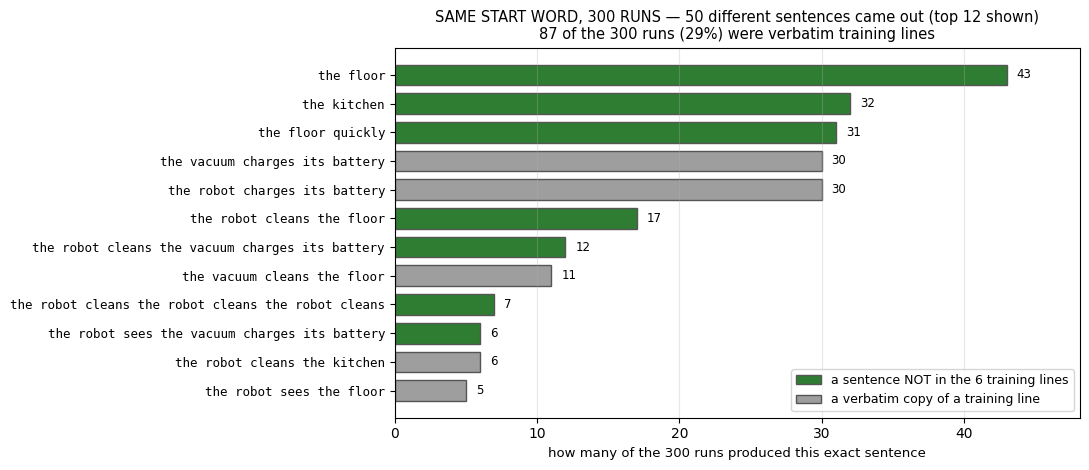

One start word ('the'), 300 runs -> 50 distinct sentences.
  verbatim training lines :  87 runs (29%)
  sentences never written : 213 runs (71%)


In [7]:
# ── Picture 3: the same one prompt, run 300 times ───────────────────────────
# WHAT: start from the same word 300 times and count how often each exact sentence
#       comes out, marking which of them are verbatim training lines.
# WHY : the Zarya of the Dawn decision turned on one technical fact — a generative
#       model SAMPLES, so one input does not determine one output. That is a claim
#       about a distribution, and a distribution is something you have to look at.
from matplotlib.patches import Patch

random.seed(0)                        # fixed so the classroom sees the same picture
N_RUNS = 300
outs = Counter(generate_sentence('the') for _ in range(N_RUNS))
n_train_runs = sum(c for s, c in outs.items() if s in training_lines)

fig3, ax3 = plt.subplots(figsize=(11.0, 4.8))
top = outs.most_common(12)
labels = [s for s, _ in top][::-1]
counts_shown = [c for _, c in top][::-1]
bar_colours = ['#9e9e9e' if s in training_lines else '#2e7d32' for s in labels]
y = np.arange(len(labels))
ax3.barh(y, counts_shown, color=bar_colours, edgecolor='#555555', height=0.72)
ax3.set_yticks(y); ax3.set_yticklabels(labels, fontsize=9, family='monospace')
ax3.set_xlabel(f'how many of the {N_RUNS} runs produced this exact sentence', fontsize=9.5)
for yy, c in zip(y, counts_shown):
    ax3.text(c + 0.7, yy, str(c), va='center', fontsize=8.5)
ax3.set_xlim(0, max(counts_shown) * 1.12)
ax3.legend(handles=[Patch(facecolor='#2e7d32', edgecolor='#555',
                          label='a sentence NOT in the 6 training lines'),
                    Patch(facecolor='#9e9e9e', edgecolor='#555',
                          label='a verbatim copy of a training line')],
           loc='lower right', fontsize=9, frameon=True)
ax3.set_title(f'SAME START WORD, {N_RUNS} RUNS — {len(outs)} different sentences came out '
              f'(top 12 shown)\n{n_train_runs} of the {N_RUNS} runs '
              f'({100 * n_train_runs / N_RUNS:.0f}%) were verbatim training lines',
              fontsize=10.5)
ax3.grid(axis='x', alpha=0.3)
fig3.tight_layout()
plt.show()

print(f"One start word ('the'), {N_RUNS} runs -> {len(outs)} distinct sentences.")
print(f"  verbatim training lines : {n_train_runs:3d} runs ({100 * n_train_runs / N_RUNS:.0f}%)")
print(f"  sentences never written : {N_RUNS - n_train_runs:3d} runs "
      f"({100 * (N_RUNS - n_train_runs) / N_RUNS:.0f}%)")


### 👁️ Read the 300-run distribution

The start word never changes — every one of the 300 runs begins at `the`, exactly as in
the storyboard above — and **50 different sentences came out**. The bars are the twelve
commonest.

- **Grey bars are verbatim training lines.** Five of the top twelve bars are grey, and
  across all 300 runs they account for **87 runs (29%)**. Roughly three runs in ten
  handed back a sentence from the training data word for word. Memorisation is not an
  exotic failure that appears at scale — it is the *default* behaviour of a small model,
  which scale only partially hides. That is why the **privacy** row of the ethics table
  above is a live risk and not a hypothetical one.
- **Green bars are sentences nobody ever wrote** — including
  `the robot cleans the vacuum charges its battery`, grammatical nonsense the model is
  exactly as happy to produce as the good ones. Fluency and correctness are separate
  properties, and only one of them is being optimised.

**This is the technical fact the copyright decision turned on.** The person who supplied
the start word did not choose between these 50 outcomes; the table in Picture 1 and the
dice in Picture 2 did. In the US Copyright Office's words, the prompt "may 'influence'
the generated image, but prompt text does not dictate a specific result" — and this bar
chart is what "does not dictate a specific result" looks like when you can count it.


## 💬 Discuss

Look hard at the Markov chain's actual output above — including
`the vacuum charges its battery` (a sentence that was never in the six training
lines) and `the floor` (a sentence nobody would write). Argue:

1. The model produced a sentence its training corpus did not contain. **Is that
   creativity, recombination, or neither?** Now scale the argument up: does your
   answer change when the model has billions of parameters instead of a frequency
   table over eleven words? Say what actually changed and what did not.
2. Under the *Zarya of the Dawn* reasoning, who — if anyone — owns
   `the robot sees the floor quickly`? The person who wrote the six training
   sentences, the person who ran the cell, or nobody? Argue it, then argue the
   other side.
3. The ethics table above lists bias, misinformation, IP and privacy with a
   "mitigation" for each. Pick the one you think is *least* solved by its listed
   mitigation and defend that choice. What would change your mind?


## Summary

In this notebook, we learned:
- Generative AI creates new content (vs. discriminative AI that classifies)
- Main types: GANs, VAEs, Transformers, Diffusion Models
- Applications: text, image, audio, video generation
- Ethical considerations: bias, misinformation, IP, privacy
- Hands-on: a word-level Markov chain that learned next-word counts from a
  six-sentence corpus and generated new sentences by sampling them

**Next Steps:**
- Complete exercises in `exercises/` folder
- Explore Course 10 (AIAT 124) for deep dive into Generative AI
- Take quiz in `quizzes/` folder

**Full Coverage:** Complete Generative AI course is in Semester 2, Course 10 (AIAT 124)

## ⚠️ Where this breaks

**Start with the model you just ran.** The Markov chain is a real generative
model, and its limits are visible in its own printed output.

- **It has a memory of exactly one word.** `the → ['robot', 'kitchen', 'robot',
  'vacuum', 'floor', ...]` is the whole model. It cannot keep a subject consistent
  across a sentence, cannot close a bracket it opened, and cannot answer a question
  asked three words ago. Everything that makes modern language models useful is a
  fix for this one limitation.
- **It can only ever emit words it has seen.** Ask it about a *dishwasher* and it
  has nothing — no output, not a wrong output. Its vocabulary is a hard wall.
- **It reproduces training data.** Several generated lines above are verbatim
  training sentences, because with six sentences there is nowhere else to go.
  Memorisation is not a bug that appears at scale; it is the default that scale
  partially hides — which is exactly why the *privacy* row in the ethics table is
  a real risk and not a theoretical one.
- **It has no notion of truth, and neither do its larger descendants.** The chain
  emitted `the floor` as a complete sentence with the same mechanism that produced
  the good ones. Fluency and correctness are separate properties, and only one of
  them is being optimised.

**Where the framing of this notebook breaks:**

- **The four-family table is a snapshot, not a hierarchy.** GANs, VAEs,
  transformers and diffusion models are listed as peers. In practice the live
  lineage for images runs latent diffusion → transformer backbones (Peebles & Xie,
  2022, *Scalable Diffusion Models with Transformers*) → flow matching, and GANs
  are now mostly of historical and educational interest. You will still train one
  in Unit 5 — because it is the clearest way to *see* an adversarial training
  signal — not because it is what you would reach for in 2026.
- **"Generative vs discriminative" is a description of the objective, not a
  description of the product.** A useful system is usually both: a generator
  wrapped in classifiers that filter, rank and refuse its output.

**When not to reach for a generative model at all:** when a correct answer exists
and can be looked up. If the question is "what is this customer's balance", a
database query is right and a generated sentence is a liability.


## 📚 References

1. Goodfellow, I., Pouget-Abadie, J., Mirza, M., et al. (2014). *Generative Adversarial Nets*. NeurIPS. <https://arxiv.org/abs/1406.2661>
2. Kingma, D. P., & Welling, M. (2014). *Auto-Encoding Variational Bayes*. ICLR. <https://arxiv.org/abs/1312.6114>
3. Ho, J., Jain, A., & Abbeel, P. (2020). *Denoising Diffusion Probabilistic Models*. NeurIPS. <https://arxiv.org/abs/2006.11239>
4. Bommasani, R., Hudson, D. A., Adeli, E., et al. (2021). *On the Opportunities and Risks of Foundation Models*. arXiv. <https://arxiv.org/abs/2108.07258>
5. Zhao, S., Zhang, X., Guo, J., et al. (2025). *Unified Multimodal Understanding and Generation Models: Advances, Challenges, and Opportunities*. arXiv. <https://arxiv.org/abs/2505.02567>
6. Li, L., Long, Z., Shen, Y., et al. (2026). *Omni-Diffusion: Unified Multimodal Understanding and Generation with Masked Discrete Diffusion*. arXiv. <https://arxiv.org/abs/2603.06577>